# 03 - Modelagem e Avaliação
## Tech Challenge Fase 1 - Saúde e Segurança da Mulher
**Responsável:** Rodrigo

---

### Objetivo
Treinar, avaliar e comparar modelos de Machine Learning para classificação de tumores mamários. Implementar explicabilidade com SHAP e discutir a aplicabilidade prática.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../..')

from src.data_loader import load_breast_cancer_dataset
from src.preprocessing import full_preprocessing_pipeline
from src.models import create_models, train_all_models, save_model
from src.evaluation import (
    evaluate_all_models,
    plot_confusion_matrix,
    plot_roc_curves,
    explain_with_shap,
    explain_knn_with_shap,
    get_feature_importance
)

%matplotlib inline

## 1. Preparação dos Dados

In [2]:
# Carregar e preprocessar
df = load_breast_cancer_dataset()

pipeline = full_preprocessing_pipeline(
    df, target_col='target', drop_cols=['diagnosis'], test_size=0.2
)

X_train = pipeline['X_train']
X_test = pipeline['X_test']
y_train = pipeline['y_train']
y_test = pipeline['y_test']
feature_names = pipeline['feature_names']

Dataset carregado do sklearn.datasets
Shape: (569, 32)
Colunas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'diagnosis']

PIPELINE DE PRÉ-PROCESSAMENTO

1. Colunas removidas: ['diagnosis']

2. Tratamento de valores ausentes:
Valores nulos restantes: 0

3. Codificação de variáveis categóricas:

4. Features: 30 | Target: 'target'

5. Padronização:
Features padronizadas com standardScaler

6. Separação treino/teste:
Dados separados:
  Treino: 455 amostras (

## 2. Criação e Treinamento dos Modelos

In [3]:
# Criar modelos
models = create_models()

# Treinar todos
trained_models = train_all_models(models, X_train, y_train)

Acurácia no treino: 0.9736
Treinando Árvore de Decisão... Acurácia no treino: 1.0000
Treinando XGBoost... Acurácia no treino: 1.0000
Todos os 5 modelos treinados com sucesso!


## 3. Avaliação dos Modelos

In [4]:
# Avaliar todos os modelos
results_df = evaluate_all_models(trained_models, X_test, y_test)
results_df

,accuracy,precision,recall,f1_score,auc_roc
modelo,,,,,
KNN,0.964912,0.965185,0.964912,0.964725,0.979167
Regressão Logística,0.956140,0.958098,0.956140,0.956430,0.995370
XGBoost,0.956140,0.956869,0.956140,0.955776,0.994048
Random Forest,0.947368,0.947368,0.947368,0.947368,0.994048
Árvore de Decisão,0.929825,0.931066,0.929825,0.930146,0.929563


In [5]:
# Salvar resultados
results_df.to_csv('../../results/comparacao_modelos.csv')
print("Resultados salvos em results/comparacao_modelos.csv")

Resultados salvos em results/comparacao_modelos.csv


## 4. Matrizes de Confusão

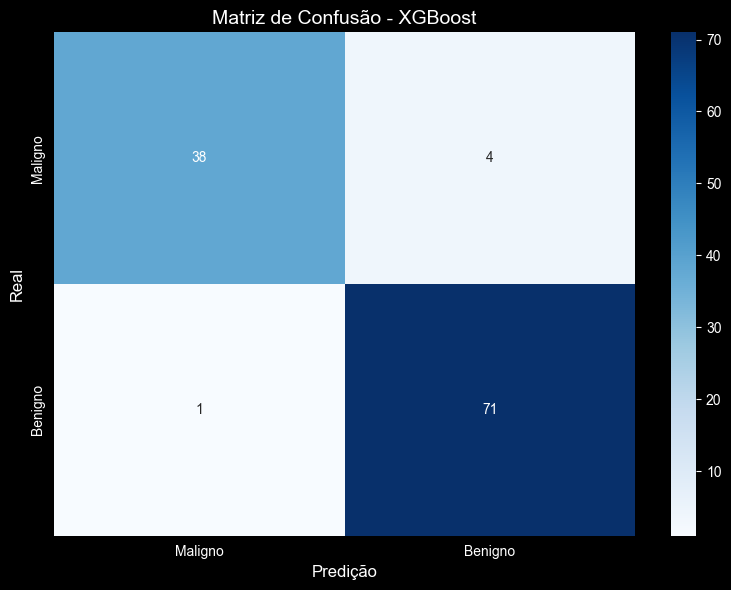

In [6]:
# Matriz de confusão para cada modelo
for name, model in trained_models.items():
    save_path = f'../../reports/figures/confusion_matrix_{name.replace(" ", "_")}.png'
    plot_confusion_matrix(model, X_test, y_test, name, save_path=save_path)

## 5. Curvas ROC

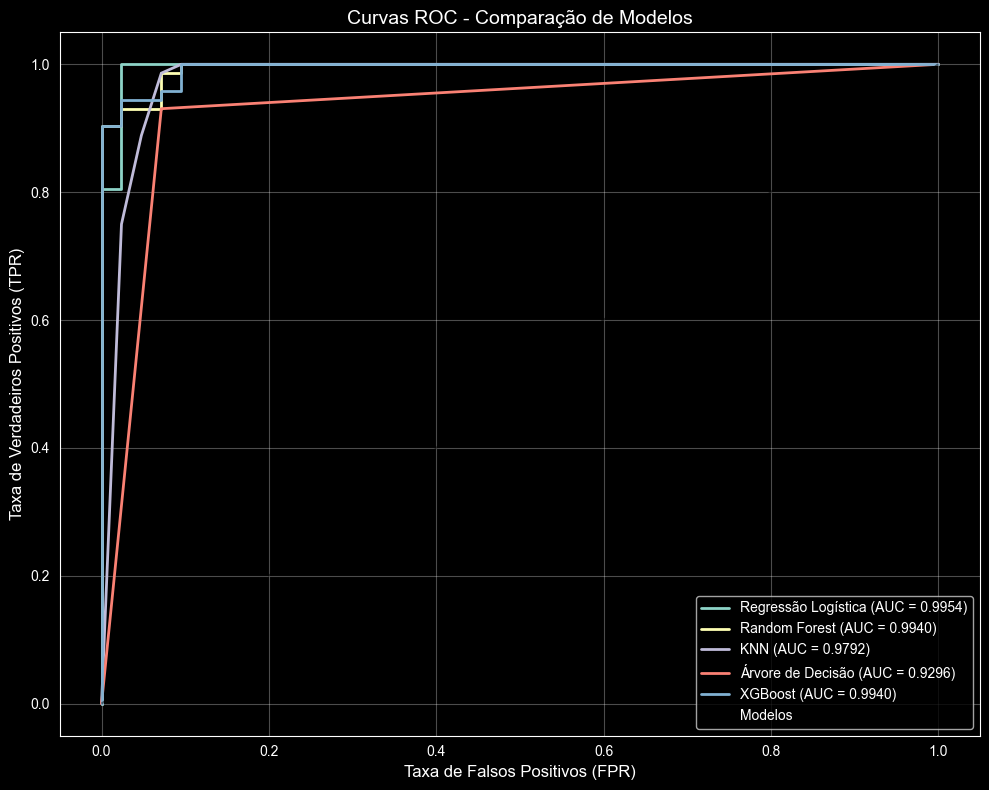

In [7]:
# Curvas ROC comparativas
plot_roc_curves(trained_models, X_test, y_test,
                save_path='../../reports/figures/curvas_roc.png')

## 6. Feature Importance

In [8]:
# Feature importance para Random Forest
get_feature_importance(
    trained_models['Random Forest'], feature_names,
    'Random Forest',
    save_path='../../reports/figures/feature_importance_rf.png'
)

,feature,importance
9,mean fractal dimension,0.002949
14,smoothness error,0.003320
18,symmetry error,0.003351
16,concavity error,0.003635
19,fractal dimension error,0.003772
17,concave points error,0.003958
8,mean symmetry,0.004192
11,texture error,0.004387
29,worst fractal dimension,0.005289
15,compactness error,0.006182


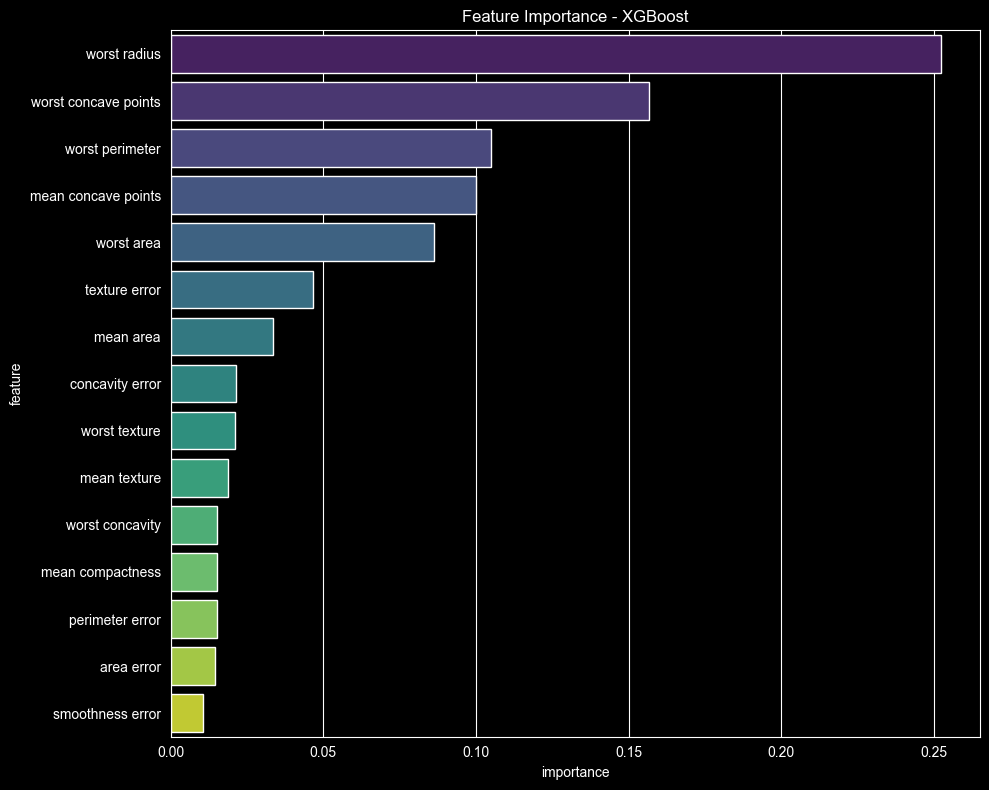

In [16]:
# Feature importance para XGBoost
xgb_model = trained_models['XGBoost']

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

display(importance_df)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
save_path = '../../reports/figures/feature_importance_xgboost.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

## 7. Explicabilidade com SHAP

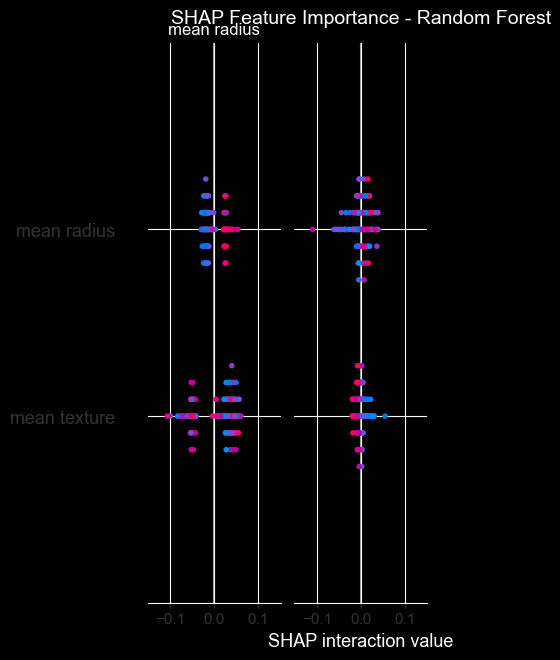

In [10]:
# SHAP para Random Forest
shap_values = explain_with_shap(
    trained_models['Random Forest'], X_test, feature_names,
    model_name='Random Forest',
    save_dir='../../reports/figures'
)

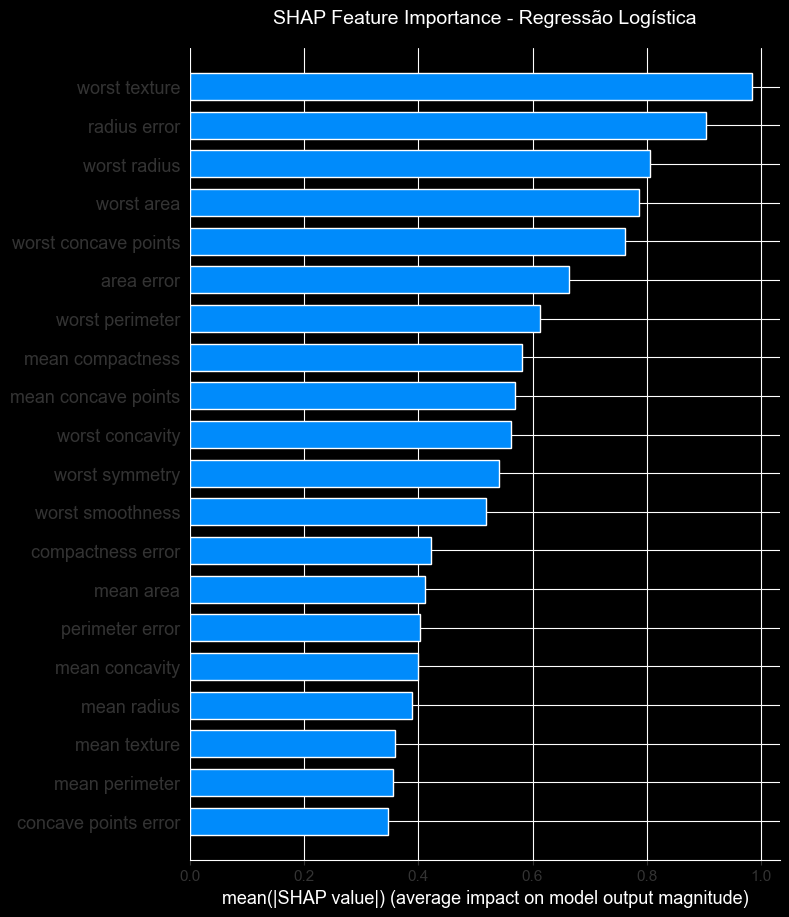

In [11]:
# SHAP para Regressão Logística
shap_values_lr = explain_with_shap(
    trained_models['Regressão Logística'], X_test, feature_names,
    model_name='Regressão Logística',
    save_dir='../../reports/figures'
)

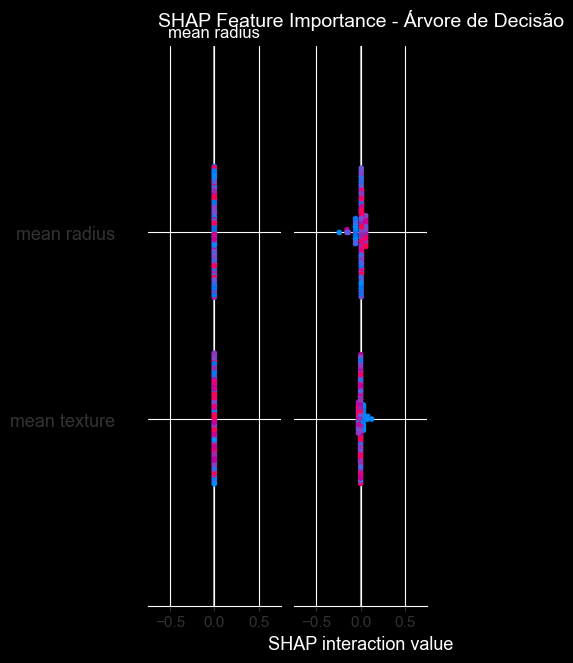

In [12]:
# SHAP para Árvore de Decisão
shap_values_tree = explain_with_shap(
    trained_models['Árvore de Decisão'], X_test, feature_names,
    model_name='Árvore de Decisão',
    save_dir='../../reports/figures'
)

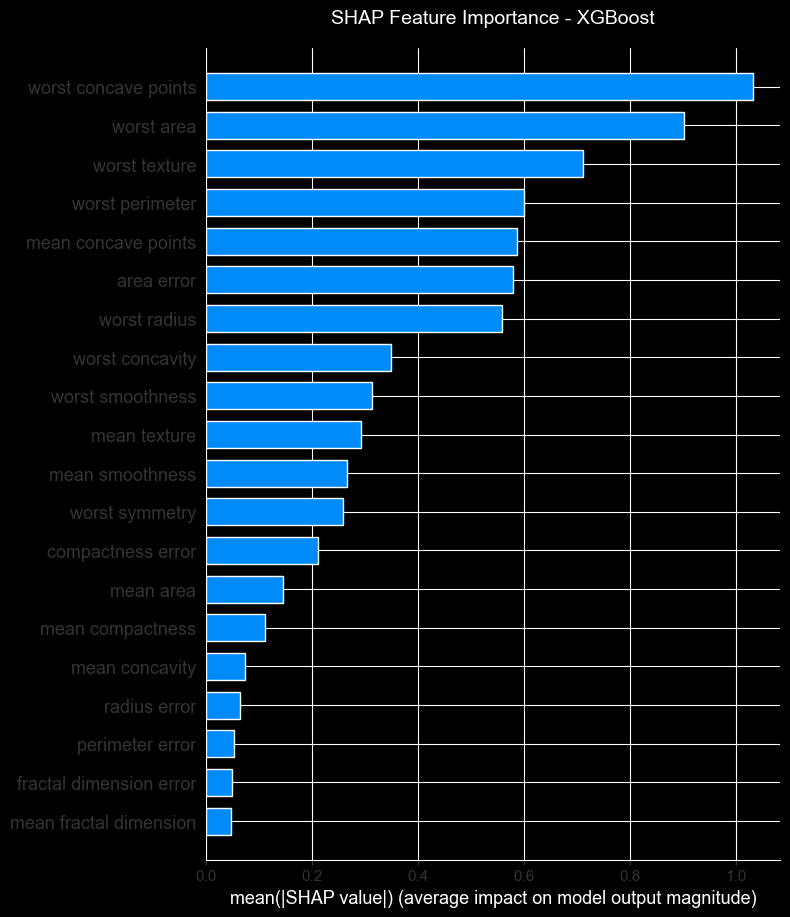

In [13]:
# SHAP para XGBoost
shap_values = explain_with_shap(
    trained_models['XGBoost'], X_test, feature_names,
    model_name='XGBoost',
    save_dir='../../reports/figures'
)

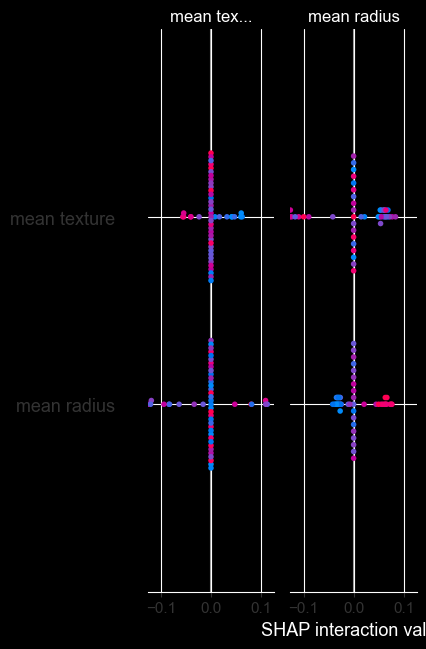

In [14]:
# # SHAP para KNN (com KernelExplainer)
# shap_values = explain_with_shap(
#     trained_models['KNN'], X_test, feature_names,
#     model_name='KNN',
#     save_dir='../../reports/figures',
#     explainer_type='kernel'
# )
# SHAP para KNN
shap_values_knn = explain_knn_with_shap(
    trained_models['KNN'], X_train, X_test, feature_names,
    model_name='KNN',
    save_dir='../../reports/figures'
)

## 8. Salvar Melhor Modelo

In [15]:
# Identificar e salvar o melhor modelo (por recall)
best_model_name = results_df['recall'].idxmax()
print(f"Melhor modelo (por Recall): {best_model_name}")
print(f"Recall: {results_df.loc[best_model_name, 'recall']:.4f}")

save_model(trained_models[best_model_name], '../../results/best_model.joblib')

Melhor modelo (por Recall): KNN
Recall: 0.9649
Modelo salvo em: ../../results/best_model.joblib


## 9. Discussão Crítica dos Resultados



### 9.1 Comparação dos Modelos

Neste projeto, foram avaliados os modelos de Regressão Logística, Random Forest, XGBoost, Árvore de Decisão e KNN para a classificação de tumores mamários. Entre os modelos avaliados, o **KNN** foi selecionado como melhor modelo final, pois apresentou o melhor desempenho considerando a métrica principal definida para o projeto, o **recall**. O modelo alcançou recall de **0.9649**, indicando alta capacidade de identificar corretamente os casos positivos no conjunto de teste.

A escolha do KNN como melhor modelo não significa necessariamente que ele tenha superado os demais em todas as métricas, mas sim que foi o mais adequado ao objetivo central do problema. Em um contexto de diagnóstico médico, detectar corretamente o maior número possível de casos positivos é mais importante do que maximizar apenas a acurácia global.

A Regressão Logística, o Random Forest, o XGBoost e a Árvore de Decisão também apresentaram desempenho relevante, mas ficaram atrás do KNN no critério mais sensível para o problema. Além disso, o KNN pode capturar relações locais entre os dados, o que pode ser vantajoso em bases com fronteiras de decisão menos lineares.




### Escolha da métrica principal

Neste projeto, a métrica principal escolhida foi o **recall**, pois o problema analisado está inserido em um contexto de diagnóstico médico. Nessa situação, o principal risco é a ocorrência de falsos negativos, isto é, casos em que uma paciente com possível câncer seja classificada incorretamente como não doente.

Em aplicações clínicas, um falso negativo pode atrasar o diagnóstico, comprometer o encaminhamento para exames complementares e impactar negativamente o tratamento. Por isso, embora métricas como accuracy, precision, F1-score e AUC-ROC também sejam importantes para uma avaliação mais completa, o recall recebe maior prioridade neste estudo.

Dessa forma, o modelo considerado mais adequado é aquele com maior capacidade de identificar corretamente os casos positivos, mesmo que isso implique a ocorrência de alguns falsos positivos adicionais. Em um sistema de apoio à decisão médica, esse trade-off é aceitável, pois exames complementares podem confirmar ou descartar a suspeita clínica posteriormente.

### 9.2 Interpretação dos Resultados (SHAP)

A análise de explicabilidade com SHAP permitiu identificar quais variáveis mais influenciaram as previsões dos modelos. De modo geral, as features mais relevantes estiveram associadas a medidas morfológicas do tumor, como raio, perímetro, área, concavidade e concave points, que são atributos frequentemente reconhecidos como importantes na distinção entre tumores benignos e malignos.

Os gráficos SHAP mostraram não apenas a importância global das variáveis, mas também a direção do impacto de cada feature sobre a predição. Isso contribui para uma interpretação mais transparente do modelo, permitindo entender como determinadas características empurram a decisão para classes de maior ou menor risco.

Do ponto de vista clínico, os resultados fazem sentido, pois refletem características estruturais do tumor que costumam estar relacionadas à malignidade. Ainda assim, a interpretação deve ser vista como apoio analítico e não como substituição da avaliação médica especializada.

### 9.3 Aplicabilidade Prática


O modelo desenvolvido pode ser utilizado como uma ferramenta de apoio à decisão clínica, auxiliando profissionais de saúde na triagem inicial de casos com maior probabilidade de malignidade. Nesse cenário, o sistema poderia funcionar como um mecanismo complementar para priorização de pacientes, sinalização de risco e suporte à análise diagnóstica.

Entretanto, é fundamental destacar que o modelo não deve ser utilizado de forma autônoma para emissão de diagnóstico. A decisão final deve permanecer sob responsabilidade do médico, que considera também exames de imagem, histórico clínico, contexto da paciente e outros fatores que não estão presentes no dataset.

Em um ambiente hospitalar, a integração prática do sistema poderia ocorrer como parte de um fluxo de apoio à análise, em que os dados das pacientes fossem processados automaticamente e o modelo retornasse uma estimativa de risco acompanhada de explicações interpretáveis. Isso aumentaria a utilidade do sistema sem comprometer a supervisão humana.

### 9.4 Limitações

Uma das principais limitações do estudo está no tamanho relativamente reduzido do dataset utilizado, com 569 amostras. Embora seja um conjunto clássico para fins educacionais e experimentais, ele não representa toda a diversidade de casos encontrados na prática clínica.

Outra limitação importante diz respeito à possibilidade de vieses nos dados, tanto em relação à origem da base quanto à distribuição das características observadas. Isso significa que o desempenho obtido no experimento pode não se repetir exatamente em outras populações, instituições ou contextos epidemiológicos.

Além disso, o pipeline atual utiliza um conjunto de teste único, o que pode tornar os resultados sensíveis à forma como a divisão foi realizada. Em trabalhos futuros, seria recomendável adotar validação cruzada, ajuste fino de hiperparâmetros e avaliação com bases externas para aumentar a robustez e a capacidade de generalização do modelo.